# INTELLIGENT SYSTEM DEVELOPMENT — ASSIGNMENT 02 (WEEK 1)
## Chuyên đề: Khám phá Dữ liệu Toàn diện (EDA) — E-Commerce Customer Reviews & Behavior
**Tập dữ liệu:** `Womens Clothing E-Commerce Reviews.csv` (23,486 dòng, 11 thuộc tính)  
**Mục tiêu:** Khám phá cấu trúc dữ liệu, phân tích phân phối đơn biến, đa biến, đặc trưng văn bản (NLP metrics) và tương quan hành vi khách hàng nhằm chuẩn bị cho việc xây dựng biểu diễn dữ liệu và mô hình máy học.

---
### 1. Khởi tạo Môi trường & Tải Dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# Thiết lập phong cách đồ họa chuyên nghiệp
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('tab10')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Tải tập dữ liệu
data_path = 'data/Womens Clothing E-Commerce Reviews.csv'
df_raw = pd.read_csv(data_path)

print(f"✅ Tải dữ liệu thành công!")
print(f"   • Số lượng quan sát (N): {df_raw.shape[0]:,} dòng")
print(f"   • Số lượng thuộc tính (d): {df_raw.shape[1]} cột")
df_raw.head()

✅ Tải dữ liệu thành công!
   • Số lượng quan sát (N): 23,486 dòng
   • Số lượng thuộc tính (d): 11 cột


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


---
### 2. Kiểm tra Cấu trúc & Chất lượng Dữ liệu (Data Inspection & Quality)

In [2]:
# 1. Tổng quan kiểu dữ liệu và bộ nhớ
print("=== THÔNG TIN KIỂU DỮ LIỆU & BỘ NHỚ ===")
df_raw.info()

# 2. Kiểm tra giá trị khuyết thiếu (Missing Values)
df_missing = pd.DataFrame({
    'Kiểu dữ liệu': df_raw.dtypes,
    'Số lượng Missing': df_raw.isna().sum(),
    'Tỷ lệ Missing (%)': (df_raw.isna().sum() / len(df_raw) * 100).round(2),
    'Số giá trị duy nhất (Unique)': df_raw.nunique()
})
print("\n=== THỐNG KÊ GIÁ TRỊ KHUYẾT THIẾU ===")
df_missing

=== THÔNG TIN KIỂU DỮ LIỆU & BỘ NHỚ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB

=== THỐNG KÊ GIÁ TRỊ KHUYẾT THIẾU ===


,Kiểu dữ liệu,Số lượng Missing,Tỷ lệ Missing (%),Số giá trị duy nhất (Unique)
Unnamed: 0,int64,0,0.00,23486
Clothing ID,int64,0,0.00,1206
Age,int64,0,0.00,77
Title,object,3810,16.22,13993
Review Text,object,845,3.60,22634
Rating,int64,0,0.00,5
Recommended IND,int64,0,0.00,2
Positive Feedback Count,int64,0,0.00,82
Division Name,object,14,0.06,3
Department Name,object,14,0.06,6


---
### 3. Tiền xử lý Sơ bộ & Tạo Đặc trưng Văn bản (Feature Engineering for EDA)

Ta thực hiện các bước chuẩn bị:
1. Loại bỏ cột chỉ số thừa `Unnamed: 0`.
2. Trích xuất độ dài ký tự (`Review_Length`) và số lượng từ (`Word_Count`) từ văn bản bình luận.
3. Tạo cờ nhị phân `Has_Title` (1 nếu có tiêu đề, 0 nếu khuyết thiếu).
4. Phân nhóm độ tuổi khách hàng (`Age_Group`) thành 4 phân khúc: `< 30`, `30 - 44`, `45 - 59`, `60+`.

In [3]:
# Tạo bản sao dữ liệu sạch để phân tích
df = df_raw.copy()

# 1. Loại bỏ cột index thừa nếu có
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# 2. Điền chuỗi rỗng tạm thời cho Title và Review Text để trích xuất đặc trưng độ dài
df['Clean_Review_Text'] = df['Review Text'].fillna('')
df['Clean_Title'] = df['Title'].fillna('')

# 3. Kỹ thuật tạo đặc trưng (Feature Engineering)
df['Review_Length'] = df['Clean_Review_Text'].apply(len)
df['Word_Count'] = df['Clean_Review_Text'].apply(lambda x: len(x.split()))
df['Has_Title'] = df['Title'].notna().astype(int)

# 4. Phân nhóm độ tuổi (Age Segment)
bins = [17, 30, 45, 60, 100]
labels = ['< 30 tuổi', '30 - 44 tuổi', '45 - 59 tuổi', '60+ tuổi']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Thống kê mô tả các biến số học
print("=== THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ HỌC SAU KHI TẠO ĐẶC TRƯNG ===")
df[['Age', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Review_Length', 'Word_Count']].describe().round(2)

=== THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ HỌC SAU KHI TẠO ĐẶC TRƯNG ===


,Age,Rating,Recommended IND,Positive Feedback Count,Review_Length,Word_Count
count,23486.00,23486.00,23486.00,23486.00,23486.00,23486.00
mean,43.20,4.20,0.82,2.54,297.58,58.03
std,12.28,1.11,0.38,5.70,152.57,30.18
min,18.00,1.00,0.00,0.00,0.00,0.00
25%,34.00,4.00,1.00,0.00,173.00,34.00
50%,41.00,5.00,1.00,1.00,292.00,57.00
75%,52.00,5.00,1.00,3.00,451.00,87.00
max,99.00,5.00,1.00,122.00,508.00,115.00


---
### 4. Phân tích Đơn biến (Univariate Analysis)
#### 4.1. Phân phối Biến Mục tiêu: `Rating` và `Recommended IND`

/var/folders/x0/279_kvcj3dvbd1fkpvt_8j7r0000gn/T/ipykernel_50543/2099401864.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, ax=axes[0], palette='Blues_r')


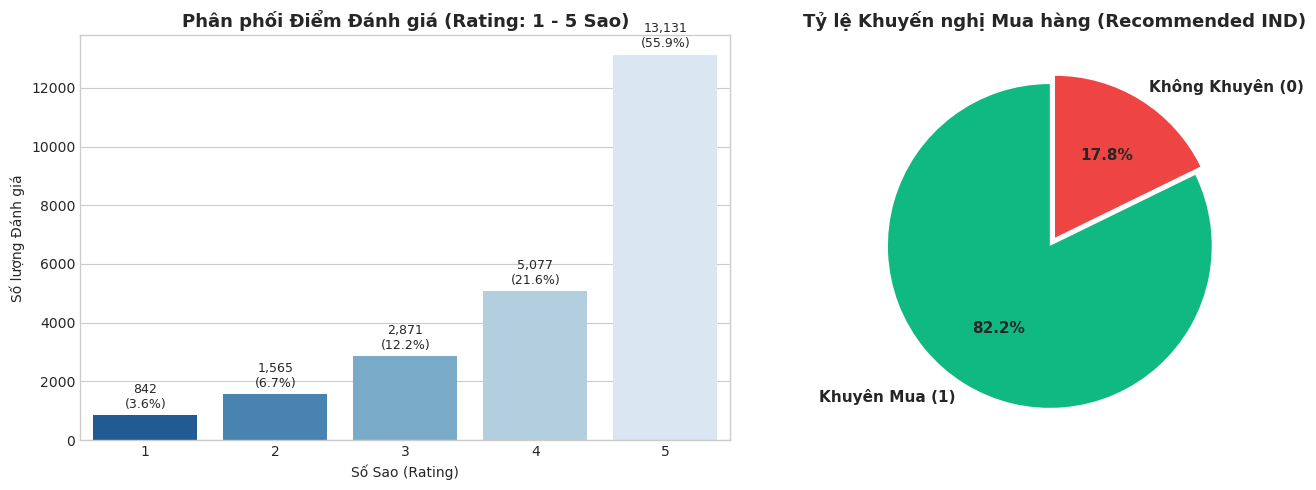

Nhận xét:
• Rating = 5 sao chiếm đa số áp đảo với 13,131 lượt (55.9%).
• Tỷ lệ khách khuyên mua đạt 82.2% vs không khuyên là 17.8%.
• Ý nghĩa ML: Dữ liệu bị mất cân bằng lớp (Class Imbalance ~ 82% vs 18%). Cần lưu ý sử dụng F1-score, Balanced Class Weights hoặc Stratified Split khi huấn luyện.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Phân phối Rating
rating_counts = df['Rating'].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Phân phối Điểm Đánh giá (Rating: 1 - 5 Sao)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số Sao (Rating)')
axes[0].set_ylabel('Số lượng Đánh giá')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}\n({p.get_height()/len(df)*100:.1f}%)',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# 2. Phân phối Recommended IND
rec_counts = df['Recommended IND'].value_counts()
colors = ['#10b981', '#ef4444']
axes[1].pie(rec_counts.values, labels=['Khuyên Mua (1)', 'Không Khuyên (0)'],
            autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.06, 0),
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Tỷ lệ Khuyến nghị Mua hàng (Recommended IND)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Nhận xét:")
print(f"• Rating = 5 sao chiếm đa số áp đảo với {rating_counts[5]:,} lượt ({rating_counts[5]/len(df)*100:.1f}%).")
print(f"• Tỷ lệ khách khuyên mua đạt {rec_counts[1]/len(df)*100:.1f}% vs không khuyên là {rec_counts[0]/len(df)*100:.1f}%.")
print(f"• Ý nghĩa ML: Dữ liệu bị mất cân bằng lớp (Class Imbalance ~ 82% vs 18%). Cần lưu ý sử dụng F1-score, Balanced Class Weights hoặc Stratified Split khi huấn luyện.")

#### 4.2. Phân phối Độ tuổi Khách hàng & Độ dài Văn bản Bình luận

/var/folders/x0/279_kvcj3dvbd1fkpvt_8j7r0000gn/T/ipykernel_50543/2398529359.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_grp_counts.index, y=age_grp_counts.values, ax=axes[2], palette='mako')


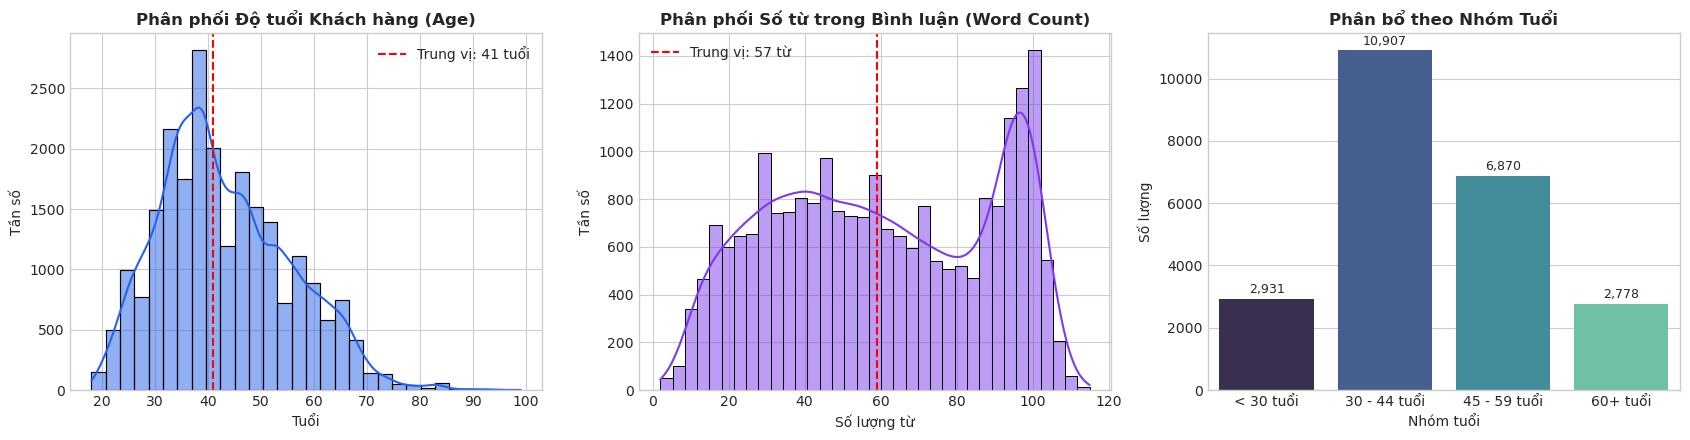

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# 1. Phân phối Độ tuổi
sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0], color='#2563eb')
axes[0].axvline(df['Age'].median(), color='red', linestyle='--', label=f'Trung vị: {df["Age"].median():.0f} tuổi')
axes[0].set_title('Phân phối Độ tuổi Khách hàng (Age)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tuổi')
axes[0].set_ylabel('Tần số')
axes[0].legend()

# 2. Phân phối Số từ trong Review
sns.histplot(df[df['Word_Count'] > 0]['Word_Count'], bins=35, kde=True, ax=axes[1], color='#7c3aed')
axes[1].axvline(df[df['Word_Count'] > 0]['Word_Count'].median(), color='red', linestyle='--', label=f'Trung vị: {df["Word_Count"].median():.0f} từ')
axes[1].set_title('Phân phối Số từ trong Bình luận (Word Count)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số lượng từ')
axes[1].set_ylabel('Tần số')
axes[1].legend()

# 3. Phân phối Phân khúc Độ tuổi
age_grp_counts = df['Age_Group'].value_counts()
sns.barplot(x=age_grp_counts.index, y=age_grp_counts.values, ax=axes[2], palette='mako')
axes[2].set_title('Phân bổ theo Nhóm Tuổi', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Nhóm tuổi')
axes[2].set_ylabel('Số lượng')
for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()

#### 4.3. Phân cấp Ngành hàng & Danh mục Sản phẩm (`Department Name` & `Class Name`)

/var/folders/x0/279_kvcj3dvbd1fkpvt_8j7r0000gn/T/ipykernel_50543/2820212994.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_counts.values, y=dept_counts.index, ax=axes[0], palette='viridis')
/var/folders/x0/279_kvcj3dvbd1fkpvt_8j7r0000gn/T/ipykernel_50543/2820212994.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_classes.values, y=top_classes.index, ax=axes[1], palette='rocket')


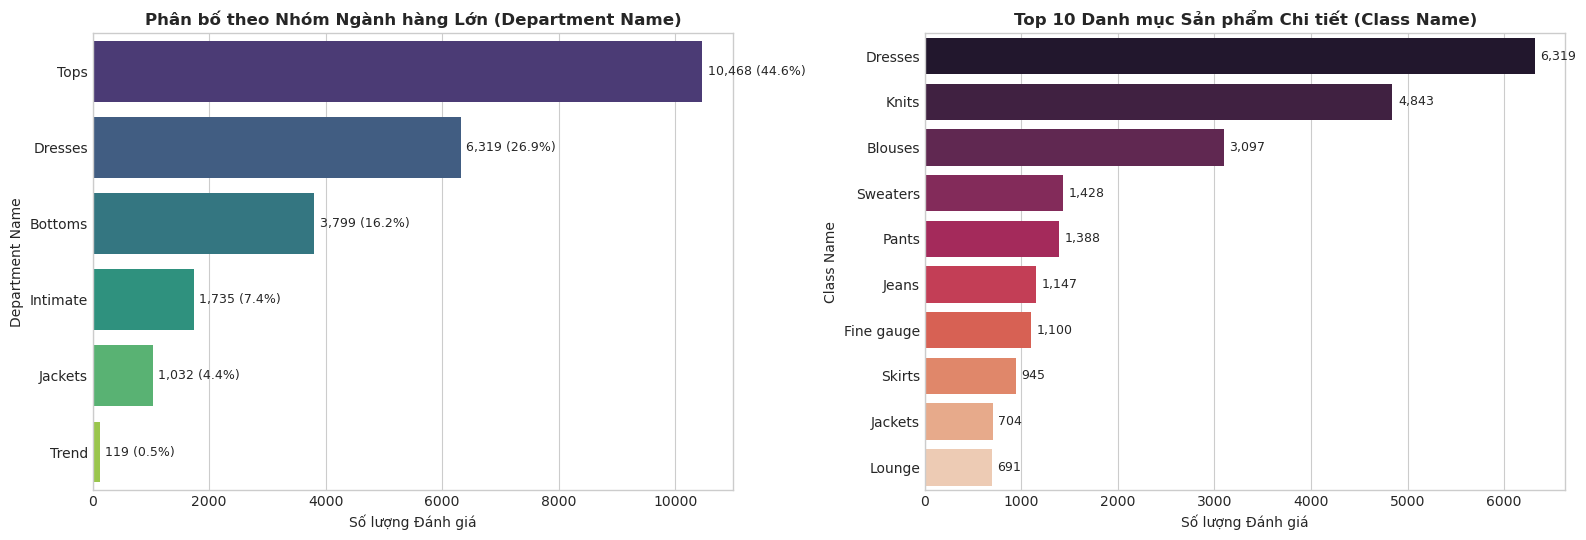

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# 1. Department Name Distribution
dept_counts = df['Department Name'].value_counts()
sns.barplot(x=dept_counts.values, y=dept_counts.index, ax=axes[0], palette='viridis')
axes[0].set_title('Phân bố theo Nhóm Ngành hàng Lớn (Department Name)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số lượng Đánh giá')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width()):,} ({p.get_width()/len(df.dropna(subset=["Department Name"]))*100:.1f}%)',
                     (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=9, xytext=(4, 0), textcoords='offset points')

# 2. Top 10 Class Name Distribution
top_classes = df['Class Name'].value_counts().head(10)
sns.barplot(x=top_classes.values, y=top_classes.index, ax=axes[1], palette='rocket')
axes[1].set_title('Top 10 Danh mục Sản phẩm Chi tiết (Class Name)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số lượng Đánh giá')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width()):,}',
                     (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=9, xytext=(4, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

---
### 5. Phân tích Đa biến & Tương quan Hành vi (Bivariate & Multivariate Analysis)
#### 5.1. Mối quan hệ giữa Ngành hàng, Độ tuổi và Tỷ lệ Khuyên mua

/var/folders/x0/279_kvcj3dvbd1fkpvt_8j7r0000gn/T/ipykernel_50543/1801218871.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean', y='Department Name', data=dept_rec, ax=axes[0], palette='crest')
/var/folders/x0/279_kvcj3dvbd1fkpvt_8j7r0000gn/T/ipykernel_50543/1801218871.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age_Group', y='mean', data=age_rating, ax=axes[1], palette='flare')
/var/folders/x0/279_kvcj3dvbd1fkpvt_8j7r0000gn/T/ipykernel_50543/1801218871.py:28: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/miniconda3/envs/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 1

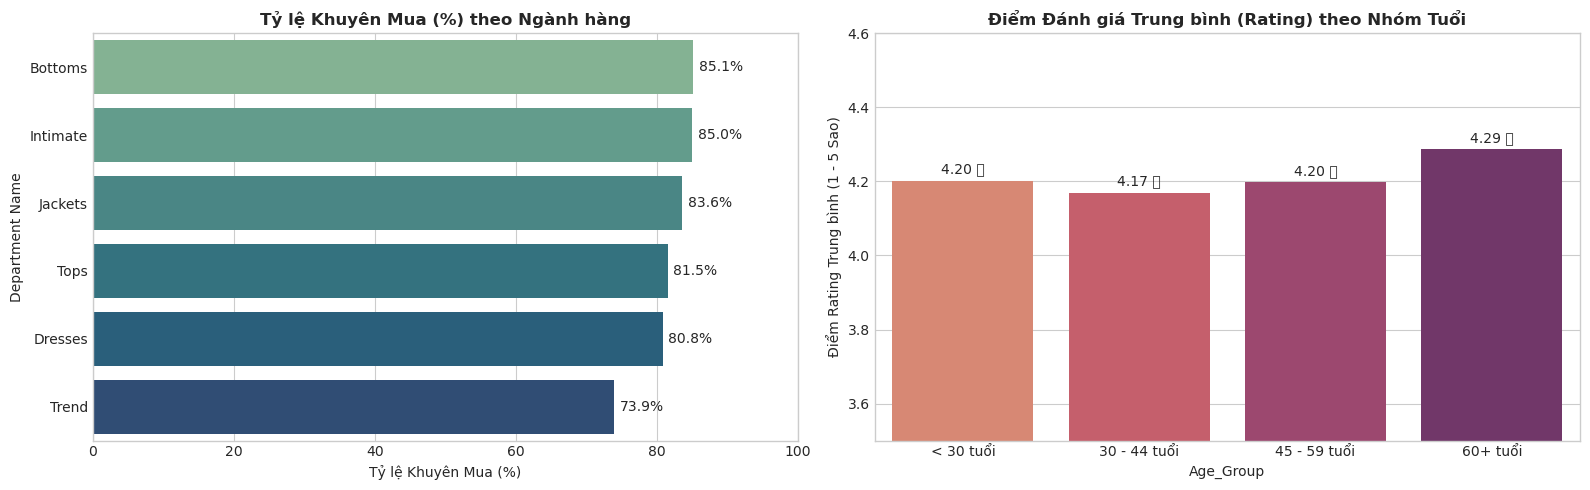

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Tỷ lệ khuyên mua theo Department Name
dept_rec = df.groupby('Department Name')['Recommended IND'].agg(['count', 'mean']).reset_index()
dept_rec['mean'] = dept_rec['mean'] * 100
dept_rec = dept_rec.sort_values(by='mean', ascending=False)

sns.barplot(x='mean', y='Department Name', data=dept_rec, ax=axes[0], palette='crest')
axes[0].set_title('Tỷ lệ Khuyên Mua (%) theo Ngành hàng', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tỷ lệ Khuyên Mua (%)')
axes[0].set_xlim(0, 100)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_width():.1f}%',
                     (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=10, xytext=(4, 0), textcoords='offset points')

# 2. Điểm đánh giá trung bình theo Nhóm Tuổi
age_rating = df.groupby('Age_Group', observed=False)['Rating'].agg(['count', 'mean']).reset_index()
sns.barplot(x='Age_Group', y='mean', data=age_rating, ax=axes[1], palette='flare')
axes[1].set_title('Điểm Đánh giá Trung bình (Rating) theo Nhóm Tuổi', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Điểm Rating Trung bình (1 - 5 Sao)')
axes[1].set_ylim(3.5, 4.6)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f} ⭐',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

#### 5.2. Hành vi Khách hàng: Người không hài lòng có viết dài hơn không?

/var/folders/x0/279_kvcj3dvbd1fkpvt_8j7r0000gn/T/ipykernel_50543/73604595.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rating', y='Word_Count', data=df[df['Word_Count'] > 0], ax=axes[0], palette='Set2')
/var/folders/x0/279_kvcj3dvbd1fkpvt_8j7r0000gn/T/ipykernel_50543/73604595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rating', y='Positive Feedback Count', data=df, ax=axes[1], palette='Set2', errorbar=None)


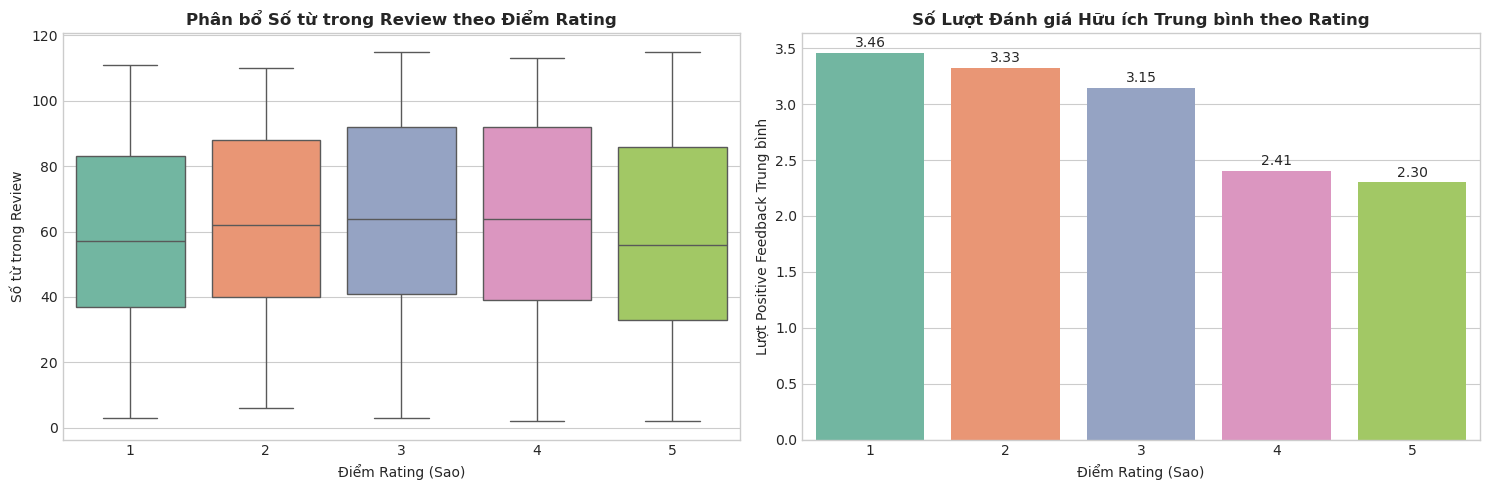

Nhận xét hành vi:
• Khách hàng đánh giá 1 - 3 sao (không hài lòng) có xu hướng viết review chi tiết và dài hơn để giải thích lỗi sản phẩm.
• Các đánh giá tiêu cực (1 - 2 sao) nhận được số lượng 'Positive Feedback Count' (lượt bấm hữu ích từ người mua khác) cao gấp đôi so với đánh giá 5 sao.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Boxplot Word Count theo Rating
sns.boxplot(x='Rating', y='Word_Count', data=df[df['Word_Count'] > 0], ax=axes[0], palette='Set2')
axes[0].set_title('Phân bổ Số từ trong Review theo Điểm Rating', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Điểm Rating (Sao)')
axes[0].set_ylabel('Số từ trong Review')

# 2. Barplot Positive Feedback Count theo Rating
sns.barplot(x='Rating', y='Positive Feedback Count', data=df, ax=axes[1], palette='Set2', errorbar=None)
axes[1].set_title('Số Lượt Đánh giá Hữu ích Trung bình theo Rating', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Điểm Rating (Sao)')
axes[1].set_ylabel('Lượt Positive Feedback Trung bình')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()

print("Nhận xét hành vi:")
print("• Khách hàng đánh giá 1 - 3 sao (không hài lòng) có xu hướng viết review chi tiết và dài hơn để giải thích lỗi sản phẩm.")
print("• Các đánh giá tiêu cực (1 - 2 sao) nhận được số lượng 'Positive Feedback Count' (lượt bấm hữu ích từ người mua khác) cao gấp đôi so với đánh giá 5 sao.")

---
### 6. Phân tích Văn bản Ngôn ngữ Tự nhiên (NLP & Keyword Discovery)
So sánh các từ khóa xuất hiện nhiều nhất giữa nhóm **Khuyên mua (Positive)** và **Không khuyên mua (Negative)**.

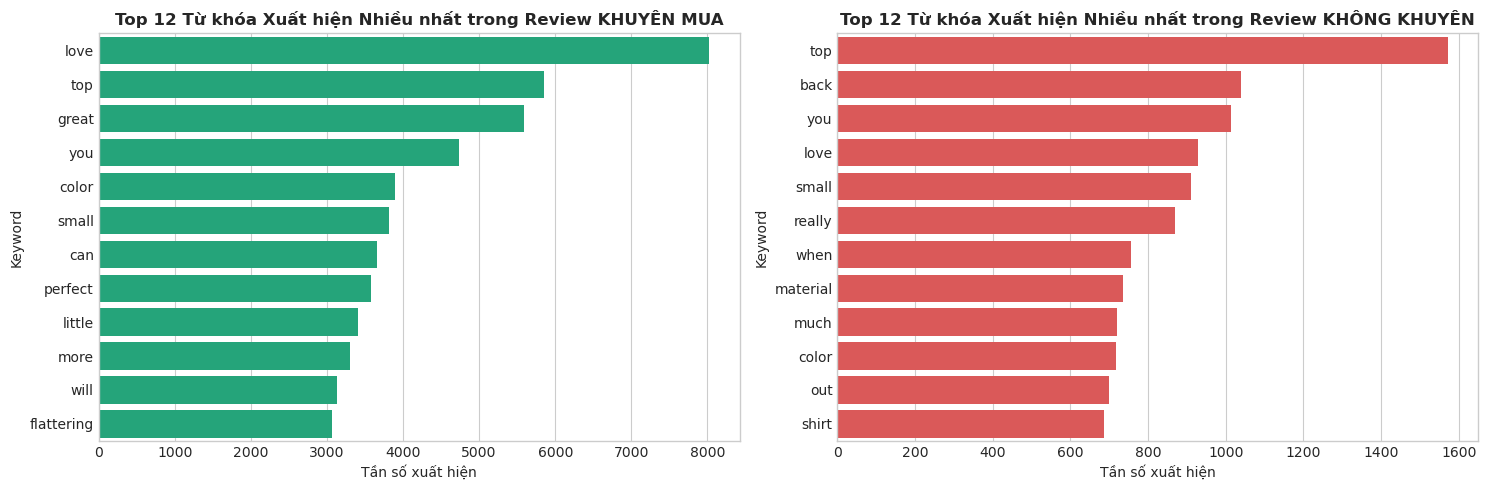

In [9]:
# Danh sách stop words tiếng Anh cơ bản để lọc từ khóa ý nghĩa
STOPWORDS = set([
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by',
    'is', 'it', 'this', 'that', 'was', 'as', 'are', 'be', 'have', 'had', 'has', 'i', 'my',
    'me', 'we', 'so', 'very', 'just', 'too', 'not', 'no', 'if', 'from', 'they', 'them', 'these',
    'fit', 'dress', 'size', 'wear', 'look', 'like', 'ordered', 'fabric', 'would', 'one', 'get'
])

def extract_top_keywords(texts, n=12):
    all_words = []
    for t in texts:
        words = re.findall(r'\b[a-zA-Z]{3,}\b', str(t).lower())
        meaningful_words = [w for w in words if w not in STOPWORDS]
        all_words.extend(meaningful_words)
    return Counter(all_words).most_common(n)

# Tách nhóm tích cực và tiêu cực
pos_reviews = df[df['Recommended IND'] == 1]['Clean_Review_Text']
neg_reviews = df[df['Recommended IND'] == 0]['Clean_Review_Text']

top_pos = extract_top_keywords(pos_reviews, 12)
top_neg = extract_top_keywords(neg_reviews, 12)

df_top_pos = pd.DataFrame(top_pos, columns=['Keyword', 'Frequency'])
df_top_neg = pd.DataFrame(top_neg, columns=['Keyword', 'Frequency'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x='Frequency', y='Keyword', data=df_top_pos, ax=axes[0], color='#10b981')
axes[0].set_title('Top 12 Từ khóa Xuất hiện Nhiều nhất trong Review KHUYÊN MUA', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tần số xuất hiện')

sns.barplot(x='Frequency', y='Keyword', data=df_top_neg, ax=axes[1], color='#ef4444')
axes[1].set_title('Top 12 Từ khóa Xuất hiện Nhiều nhất trong Review KHÔNG KHUYÊN', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tần số xuất hiện')

plt.tight_layout()
plt.show()

---
### 7. Ma trận Tương quan Đặc trưng Số học (Correlation Matrix)

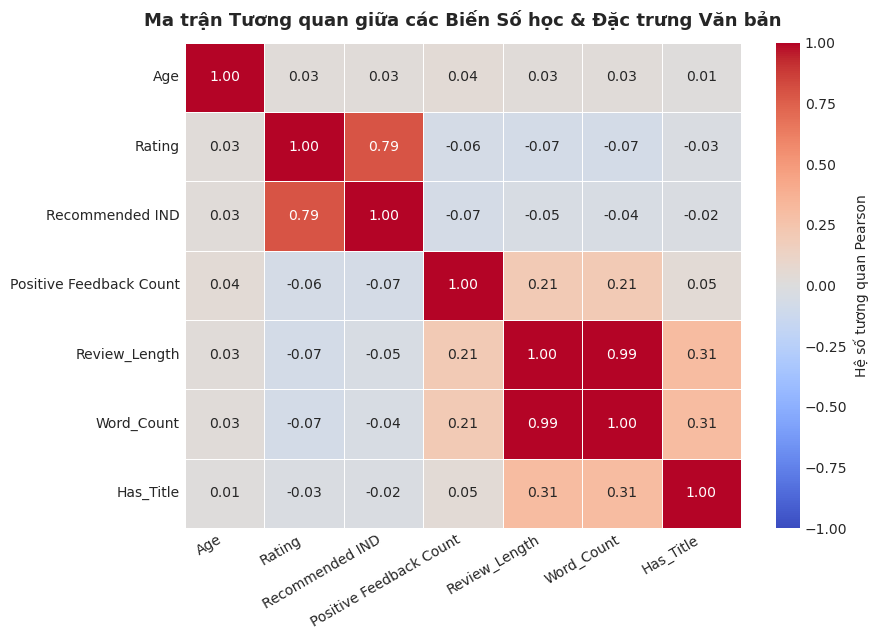

In [10]:
num_cols = ['Age', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Review_Length', 'Word_Count', 'Has_Title']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(9, 6.5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Hệ số tương quan Pearson'}
)
plt.title("Ma trận Tương quan giữa các Biến Số học & Đặc trưng Văn bản", fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
### 8. Tổng kết Khám phá Dữ liệu & Ý nghĩa đối với Xây dựng Mô hình (ML Implications)

Theo tiêu chuẩn báo cáo của Assignment 02 (Mục Part V - Exploratory Data Analysis), bảng tổng hợp các kết luận chính như sau:

| Khía cạnh Quan sát | Diễn giải Ý nghĩa Thực tế (Interpretation) | Ý nghĩa đối với Xây dựng Mô hình ML (ML Implication) |
| :--- | :--- | :--- |
| **Mất cân bằng lớp (Recommended IND)** | 82.2% khách hàng khuyên mua, chỉ 17.8% không khuyên mua. | Đánh giá mô hình bằng **F1-Score / ROC-AUC / Precision-Recall** thay vì chỉ dùng Accuracy. Áp dụng kỹ thuật `class_weight='balanced'` hoặc Stratified K-Fold. |
| **Tương quan mạnh giữa Rating & Khuyến nghị** | Rating tương quan tuyến tính rất cao với `Recommended IND` (r = 0.79). | `Rating` là đặc trưng cực mạnh nếu bài toán cho phép. Nếu bài toán dự đoán hành vi thuần túy từ bình luận (Text only), cần loại bỏ Rating để tránh Data Leakage. |
| **Độ dài văn bản (Review_Length / Word_Count)** | Review không hài lòng có xu hướng dài hơn và nhận nhiều lượt Upvote từ cộng đồng hơn. | Số lượng từ và độ dài ký tự có thể đóng vai trò là đặc trưng số học (Numerical Feature) bổ trợ cho TF-IDF / Embedding vector. |
| **Phân cấp Ngành hàng (Department Name)** | Chiếm ưu thế bởi *Tops* (44.6%) và *Dresses* (26.9%). Nhóm *Trend* có số lượng rất ít (119 mẫu). | Khi làm bài toán **Category Interest Discovery** đa lớp, cần gom nhóm hoặc chú ý Stratification để tránh overfit ở các lớp thiểu số. |
| **Chất lượng dữ liệu & Missing Values** | `Review Text` bị khuyết thiếu 845 dòng (3.6%), `Title` khuyết thiếu 3,810 dòng (16.2%). | Cần loại bỏ các dòng `Review Text` trống trước khi huấn luyện mô hình NLP, và kết hợp `Title + ' ' + Review Text` để tối đa hóa lượng thông tin ngữ cảnh. |